<a href="https://colab.research.google.com/github/shehzadtm/KhuramFiles/blob/main/iShares_Sector_ETF_dummy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
from collections import Counter
import seaborn as sns
warnings.filterwarnings('ignore')

# List of ETFs from your table
etfs = [
    "SOXX", "IYE", "IGE", "IYZ", "IYM", "IYW", "IGM", "IBB",
    "IHE", "IHF", "USRT", "IYT", "REZ", "ICF", "IAT", "IYK",
    "IFRA", "IYH", "IYR", "IYJ", "IAI", "ITA", "IYF", "IETC",
    "IYG", "IGV", "IDU", "ITB", "IYC", "IHI"
]

# ETF Name mapping
etf_names = {
    "SOXX": "iShares Semiconductor ETF",
    "IYE": "iShares U.S. Energy ETF",
    "IGE": "iShares North American Natural Resources ETF",
    "IYZ": "iShares U.S. Telecommunications ETF",
    "IYM": "iShares U.S. Basic Materials ETF",
    "IYW": "iShares U.S. Technology ETF",
    "IGM": "iShares Expanded Tech Sector ETF",
    "IBB": "iShares Biotechnology ETF",
    "IHE": "iShares U.S. Pharmaceuticals ETF",
    "IHF": "iShares U.S. Healthcare Providers ETF",
    "USRT": "iShares Core U.S. REIT ETF",
    "IYT": "iShares U.S. Transportation ETF",
    "REZ": "iShares Residential and Multisector Real Estate ETF",
    "ICF": "iShares Select U.S. REIT ETF",
    "IAT": "iShares U.S. Regional Banks ETF",
    "IYK": "iShares U.S. Consumer Staples ETF",
    "IFRA": "iShares U.S. Infrastructure ETF",
    "IYH": "iShares U.S. Healthcare ETF",
    "IYR": "iShares U.S. Real Estate ETF",
    "IYJ": "iShares U.S. Industrials ETF",
    "IAI": "iShares U.S. Broker-Dealers & Securities Exchanges ETF",
    "ITA": "iShares U.S. Aerospace & Defense ETF",
    "IYF": "iShares U.S. Financials ETF",
    "IETC": "iShares U.S. Tech Independence Focused ETF",
    "IYG": "iShares U.S. Financial Services ETF",
    "IGV": "iShares Expanded Tech-Software Sector ETF",
    "IDU": "iShares U.S. Utilities ETF",
    "ITB": "iShares U.S. Home Construction ETF",
    "IYC": "iShares U.S. Consumer Discretionary ETF",
    "IHI": "iShares U.S. Medical Devices ETF"
}

# Sector mapping
sector_mapping = {
    "Semiconductors": ["SOXX"],
    "Energy": ["IYE"],
    "Natural Resources": ["IGE"],
    "Telecommunications": ["IYZ"],
    "Basic Materials": ["IYM"],
    "Technology": ["IYW", "IGM", "IETC"],
    "Biotechnology": ["IBB"],
    "Pharmaceuticals": ["IHE"],
    "Healthcare": ["IHF", "IYH", "IHI"],
    "Real Estate": ["USRT", "REZ", "ICF", "IYR"],
    "Transportation": ["IYT"],
    "Financials": ["IAT", "IAI", "IYF", "IYG"],
    "Consumer Staples": ["IYK"],
    "Infrastructure": ["IFRA"],
    "Industrials": ["IYJ"],
    "Aerospace & Defense": ["ITA"],
    "Software": ["IGV"],
    "Utilities": ["IDU"],
    "Home Construction": ["ITB"],
    "Consumer Discretionary": ["IYC"]
}

[*********************100%***********************]  1 of 1 completed


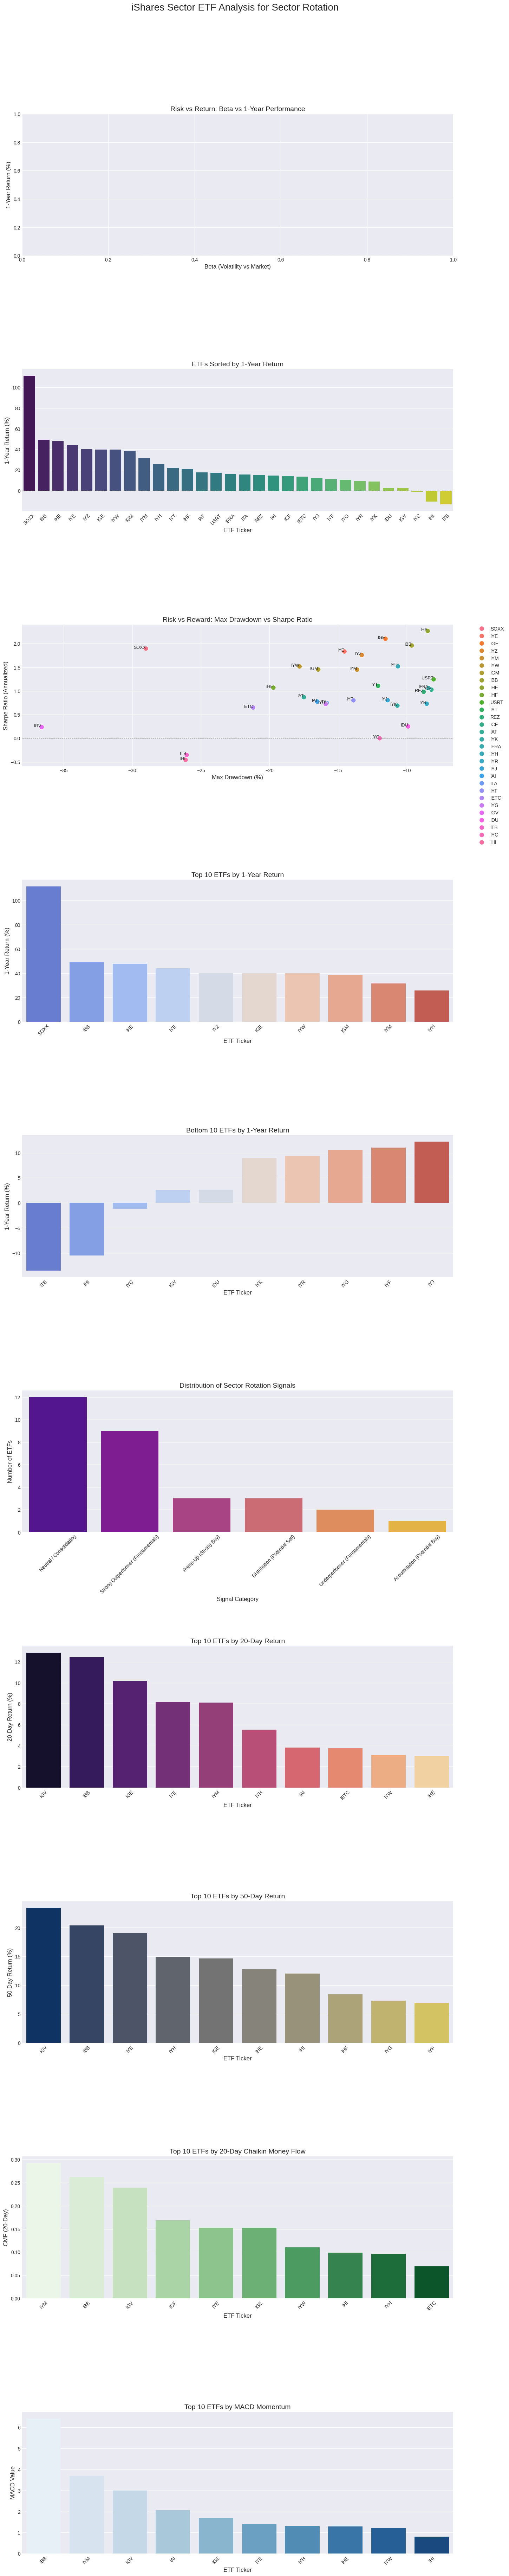

In [19]:
!pip install ta
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
from collections import Counter
import seaborn as sns
import ta # Import the Technical Analysis library
warnings.filterwarnings('ignore')

# Calculate 1-year return, YTD return, Beta, Max Drawdown, and Sharpe Ratio

# Dates for analysis
end_date = datetime.now()
year_ago = end_date - timedelta(days=365)
ytd_start = datetime(end_date.year, 1, 1)

results = []

# Function to safely get 'Adj Close' or 'Close' price
def get_price_column(df):
    if 'Adj Close' in df.columns:
        return df['Adj Close']
    elif 'Close' in df.columns:
        return df['Close']
    return pd.Series(dtype='float64') # Return empty series if neither is found

# Download market data (SPY)
market_raw_data = yf.download('SPY', start=year_ago, end=end_date)
market_data = get_price_column(market_raw_data)
market_returns = market_data.pct_change().dropna()

for ticker in etfs:
    # Download full OHLCV data for technical indicators
    data_raw = yf.download(ticker, start=year_ago, end=end_date, progress=False)

    # Ensure we have enough data for 50-day indicators (at least 50 days of data)
    # And also check for required columns for technical indicators
    required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    if data_raw.empty or len(data_raw) < 50 or not all(col in data_raw.columns for col in required_cols):
        continue

    # Use 'Close' price for return calculations and technical indicators as a base
    data_close = get_price_column(data_raw) # This will typically be 'Adj Close' or 'Close'
    if data_close.empty or len(data_close) < 2:
        continue

    # Calculate returns
    returns = data_close.pct_change().dropna()
    if len(returns) < 2:
        continue

    # 1-Year Return
    try:
        return_1y = ((data_close.iloc[-1] / data_close.iloc[0]) - 1) * 100
        # Ensure return_1y is a scalar
        if isinstance(return_1y, pd.Series) and not return_1y.empty:
            return_1y = return_1y.item()
        elif isinstance(return_1y, pd.Series) and return_1y.empty:
            return_1y = np.nan
    except IndexError:
        return_1y = np.nan

    # YTD Return
    ytd_data = data_close.loc[ytd_start:end_date]
    try:
        return_ytd = ((ytd_data.iloc[-1] / ytd_data.iloc[0]) - 1) * 100
        # Ensure return_ytd is a scalar
        if isinstance(return_ytd, pd.Series) and not return_ytd.empty:
            return_ytd = return_ytd.item()
        elif isinstance(return_ytd, pd.Series) and return_ytd.empty:
            return_ytd = np.nan
    except IndexError:
        return_ytd = np.nan

    # 20-Day Return
    try:
        if len(data_close) >= 20:
            return_20d = ((data_close.iloc[-1] / data_close.iloc[-20]) - 1) * 100
            if isinstance(return_20d, pd.Series) and not return_20d.empty:
                return_20d = return_20d.item()
            elif isinstance(return_20d, pd.Series) and return_20d.empty:
                return_20d = np.nan
        else:
            return_20d = np.nan
    except IndexError:
        return_20d = np.nan

    # 50-Day Return
    try:
        if len(data_close) >= 50:
            return_50d = ((data_close.iloc[-1] / data_close.iloc[-50]) - 1) * 100
            if isinstance(return_50d, pd.Series) and not return_50d.empty:
                return_50d = return_50d.item()
            elif isinstance(return_50d, pd.Series) and return_50d.empty:
                return_50d = np.nan
        else:
            return_50d = np.nan
    except IndexError:
        return_50d = np.nan

    # Beta (vs SPY)
    try:
        # Ensure market_returns is not empty and aligned with current ETF returns
        if not market_returns.empty and len(market_returns) > 1:
            common_index = returns.index.intersection(market_returns.index)
            if len(common_index) > 1:
                cov_matrix = np.cov(returns.loc[common_index], market_returns.loc[common_index])
                beta = cov_matrix[0, 1] / cov_matrix[1, 1]
            else:
                beta = np.nan
        else:
            beta = np.nan
    except Exception:
        beta = np.nan

    # Max Drawdown
    rolling_max = data_close.expanding(min_periods=1).max()
    daily_drawdown = data_close / rolling_max - 1.0
    max_drawdown = daily_drawdown.min() * 100
    # Ensure max_drawdown is a scalar
    if isinstance(max_drawdown, pd.Series) and not max_drawdown.empty:
        max_drawdown = max_drawdown.item()
    elif isinstance(max_drawdown, pd.Series) and max_drawdown.empty:
        max_drawdown = np.nan

    # Sharpe Ratio (assuming risk-free rate of 0 for simplicity)
    daily_returns = data_close.pct_change().dropna()
    if not daily_returns.empty and daily_returns.std().item() > 0: # Fixed: Use .item() to get scalar
        sharpe_ratio = daily_returns.mean().item() / daily_returns.std().item() * np.sqrt(252) # Annualized
    else:
        sharpe_ratio = np.nan

    # --- Technical Indicators ---
    # Ensure inputs are 1-dimensional Series for ta library
    close_series = data_raw['Close'].squeeze()
    high_series = data_raw['High'].squeeze()
    low_series = data_raw['Low'].squeeze()
    volume_series = data_raw['Volume'].squeeze()

    # MACD (standard periods: 12, 26, 9)
    macd_line = ta.trend.macd(close_series, window_fast=12, window_slow=26, fillna=False)
    macd_signal = ta.trend.macd_signal(close_series, window_fast=12, window_slow=26, window_sign=9, fillna=False)

    # Bollinger Bands (20-day and 50-day)
    bb_20_h = ta.volatility.bollinger_hband(close_series, window=20, window_dev=2, fillna=False)
    bb_20_l = ta.volatility.bollinger_lband(close_series, window=20, window_dev=2, fillna=False)
    bb_20_m = ta.volatility.bollinger_mavg(close_series, window=20, fillna=False)

    bb_50_h = ta.volatility.bollinger_hband(close_series, window=50, window_dev=2, fillna=False)
    bb_50_l = ta.volatility.bollinger_lband(close_series, window=50, window_dev=2, fillna=False)
    bb_50_m = ta.volatility.bollinger_mavg(close_series, window=50, fillna=False)

    # Chaikin Money Flow (20-day and 50-day)
    cmf_20 = ta.volume.chaikin_money_flow(
        high=high_series,
        low=low_series,
        close=close_series,
        volume=volume_series,
        window=20,
        fillna=False
    )
    cmf_50 = ta.volume.chaikin_money_flow(
        high=high_series,
        low=low_series,
        close=close_series,
        volume=volume_series,
        window=50,
        fillna=False
    )

    # Get latest values (handling potential NaN if not enough data points for indicator calculation)
    latest_close = close_series.iloc[-1] if not close_series.empty else np.nan
    latest_macd_line = macd_line.iloc[-1] if not macd_line.empty else np.nan
    latest_macd_signal = macd_signal.iloc[-1] if not macd_signal.empty else np.nan

    latest_bb_20_h = bb_20_h.iloc[-1] if not bb_20_h.empty else np.nan
    latest_bb_20_l = bb_20_l.iloc[-1] if not bb_20_l.empty else np.nan
    latest_bb_20_m = bb_20_m.iloc[-1] if not bb_20_m.empty else np.nan
    latest_bb_50_h = bb_50_h.iloc[-1] if not bb_50_h.empty else np.nan
    latest_bb_50_l = bb_50_l.iloc[-1] if not bb_50_l.empty else np.nan
    latest_bb_50_m = bb_50_m.iloc[-1] if not bb_50_m.empty else np.nan

    latest_cmf_20 = cmf_20.iloc[-1] if not cmf_20.empty else np.nan
    latest_cmf_50 = cmf_50.iloc[-1] if not cmf_50.empty else np.nan

    results.append({
        'Ticker': ticker,
        'Name': etf_names.get(ticker, 'N/A'),
        '1Y Return': return_1y,
        'YTD Return': return_ytd,
        '20D Return': return_20d,
        '50D Return': return_50d,
        'Beta': beta,
        'Max Drawdown': max_drawdown,
        'Sharpe Ratio': sharpe_ratio,
        'MACD': latest_macd_line,
        'MACD Signal': latest_macd_signal,
        'BB_20_Upper': latest_bb_20_h,
        'BB_20_Middle': latest_bb_20_m,
        'BB_20_Lower': latest_bb_20_l,
        'BB_50_Upper': latest_bb_50_h,
        'BB_50_Middle': latest_bb_50_m,
        'BB_50_Lower': latest_bb_50_l,
        'CMF_20': latest_cmf_20,
        'CMF_50': latest_cmf_50,
        'Latest Close': latest_close
    })

df_results = pd.DataFrame(results)

# --- Signal Generation ---
def generate_signal(row):
    sharpe_val = row['Sharpe Ratio']
    return_1y_val = row['1Y Return']
    return_20d_val = row['20D Return']
    return_50d_val = row['50D Return']
    latest_close = row['Latest Close']
    macd_line = row['MACD']
    macd_signal = row['MACD Signal']
    bb_20_middle = row['BB_20_Middle']
    cmf_20 = row['CMF_20']

    # Ensure values are scalar and not NaN before comparison
    if any(pd.isna(val) for val in [sharpe_val, return_1y_val, return_20d_val, return_50d_val, latest_close, macd_line, macd_signal, bb_20_middle, cmf_20]):
        return 'Insufficient Data'

    # Define conditions for different phases
    is_cmf_positive = cmf_20 > 0.05 # Strong positive money flow
    is_cmf_negative = cmf_20 < -0.05 # Strong negative money flow
    is_macd_bullish = macd_line > macd_signal and macd_line > 0 # MACD Line crosses above Signal Line and is positive
    is_macd_bearish = macd_line < macd_signal and macd_line < 0 # MACD Line crosses below Signal Line and is negative
    is_price_above_20_ma = latest_close > bb_20_middle
    is_price_below_20_ma = latest_close < bb_20_middle

    # Ramp-Up (Strong Buy)
    if is_macd_bullish and is_price_above_20_ma and is_cmf_positive and return_20d_val > 0 and return_50d_val > 0 and sharpe_val > 0.5:
        return 'Ramp-Up (Strong Buy)'
    # Accumulation (Potential Buy)
    elif cmf_20 > 0 and macd_line > macd_signal and not is_price_below_20_ma and return_1y_val > 0:
        return 'Accumulation (Potential Buy)'
    # Distribution (Potential Sell)
    elif is_cmf_negative and macd_line < macd_signal and is_price_below_20_ma and return_20d_val < 0 and return_50d_val < 0:
        return 'Distribution (Potential Sell)'
    # Downtrend (Strong Sell)
    elif is_macd_bearish and is_price_below_20_ma and is_cmf_negative and return_1y_val < 0 and sharpe_val < 0:
        return 'Downtrend (Strong Sell)'
    # Strong Outperformer (Fundamentals if technicals are neutral)
    elif return_1y_val > 20 and sharpe_val > 1.0:
        return 'Strong Outperformer (Fundamentals)'
    # Underperformer (Fundamentals if technicals are neutral)
    elif return_1y_val < -10 or sharpe_val < 0:
        return 'Underperformer (Fundamentals)'
    else:
        return 'Neutral / Consolidating'

df_results['Signal'] = df_results.apply(generate_signal, axis=1)
signal_df = df_results['Signal'].value_counts().reset_index()
signal_df.columns = ['Signal', 'Count']

# --- Visualization and Analysis ---

# Configure plot style and font sizes
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16
})

# Create a figure with 10 subplots, each on its own row (increased from 8)
fig, axes = plt.subplots(nrows=10, ncols=1, figsize=(14, 72)) # Increased figsize for more plots
fig.suptitle('iShares Sector ETF Analysis for Sector Rotation', y=1.02, fontsize=20)
fig.tight_layout(pad=5.0)

# Plot 1: Risk vs Return (Beta vs 1Y Performance)
ax1 = axes[0]
sns.scatterplot(data=df_results, x='Beta', y='1Y Return', hue='Ticker', s=100, ax=ax1, legend='full')
for i, row in df_results.iterrows():
    ax1.text(row['Beta'], row['1Y Return'], row['Ticker'], fontsize=9, ha='right')
ax1.set_title('Risk vs Return: Beta vs 1-Year Performance', fontsize=14)
ax1.set_xlabel('Beta (Volatility vs Market)', fontsize=12)
ax1.set_ylabel('1-Year Return (%)', fontsize=12)
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.axvline(1, color='gray', linestyle='--', linewidth=0.8)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Plot 2: Relative Strength vs 1Y Performance (Approximation using 1Y Return)
ax2 = axes[1]
sns.barplot(x='Ticker', y='1Y Return', data=df_results.sort_values('1Y Return', ascending=False), ax=ax2, palette='viridis')
ax2.set_title('ETFs Sorted by 1-Year Return', fontsize=14)
ax2.set_xlabel('ETF Ticker', fontsize=12)
ax2.set_ylabel('1-Year Return (%)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Plot 3: Risk vs Reward (Max Drawdown vs Sharpe Ratio)
ax3 = axes[2]
sns.scatterplot(data=df_results, x='Max Drawdown', y='Sharpe Ratio', hue='Ticker', s=100, ax=ax3, legend='full')
for i, row in df_results.iterrows():
    ax3.text(row['Max Drawdown'], row['Sharpe Ratio'], row['Ticker'], fontsize=9, ha='right')
ax3.set_title('Risk vs Reward: Max Drawdown vs Sharpe Ratio', fontsize=14)
ax3.set_xlabel('Max Drawdown (%)', fontsize=12)
ax3.set_ylabel('Sharpe Ratio (Annualized)', fontsize=12)
ax3.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Plot 4: Top 10 ETFs by 1-Year Return
top_10_1y = df_results.sort_values('1Y Return', ascending=False).head(10)
ax4 = axes[3]
sns.barplot(x='Ticker', y='1Y Return', data=top_10_1y, ax=ax4, palette='coolwarm')
ax4.set_title('Top 10 ETFs by 1-Year Return', fontsize=14)
ax4.set_xlabel('ETF Ticker', fontsize=12)
ax4.set_ylabel('1-Year Return (%)', fontsize=12)
ax4.tick_params(axis='x', rotation=45)

# Plot 5: Bottom 10 ETFs by 1-Year Return
bottom_10_1y = df_results.sort_values('1Y Return', ascending=True).head(10)
ax5 = axes[4]
sns.barplot(x='Ticker', y='1Y Return', data=bottom_10_1y, ax=ax5, palette='coolwarm')
ax5.set_title('Bottom 10 ETFs by 1-Year Return', fontsize=14)
ax5.set_xlabel('ETF Ticker', fontsize=12)
ax5.set_ylabel('1-Year Return (%)', fontsize=12)
ax5.tick_params(axis='x', rotation=45)

# Plot 6: Distribution of ETF Signals
ax6 = axes[5]
sns.barplot(x='Signal', y='Count', data=signal_df.sort_values('Count', ascending=False), ax=ax6, palette='plasma')
ax6.set_title('Distribution of Sector Rotation Signals', fontsize=14)
ax6.set_xlabel('Signal Category', fontsize=12)
ax6.set_ylabel('Number of ETFs', fontsize=12)
ax6.tick_params(axis='x', rotation=45)

# Plot 7: Top 10 ETFs by 20-Day Return
top_10_20d = df_results.sort_values('20D Return', ascending=False).head(10)
ax7 = axes[6]
sns.barplot(x='Ticker', y='20D Return', data=top_10_20d, ax=ax7, palette='magma')
ax7.set_title('Top 10 ETFs by 20-Day Return', fontsize=14)
ax7.set_xlabel('ETF Ticker', fontsize=12)
ax7.set_ylabel('20-Day Return (%)', fontsize=12)
ax7.tick_params(axis='x', rotation=45)

# Plot 8: Top 10 ETFs by 50-Day Return
top_10_50d = df_results.sort_values('50D Return', ascending=False).head(10)
ax8 = axes[7]
sns.barplot(x='Ticker', y='50D Return', data=top_10_50d, ax=ax8, palette='cividis')
ax8.set_title('Top 10 ETFs by 50-Day Return', fontsize=14)
ax8.set_xlabel('ETF Ticker', fontsize=12)
ax8.set_ylabel('50-Day Return (%)', fontsize=12)
ax8.tick_params(axis='x', rotation=45)

# Plot 9: Top 10 ETFs by CMF_20 (Recent Money Flow)
top_10_cmf_20 = df_results.sort_values('CMF_20', ascending=False).head(10)
ax9 = axes[8]
sns.barplot(x='Ticker', y='CMF_20', data=top_10_cmf_20, ax=ax9, palette='Greens')
ax9.set_title('Top 10 ETFs by 20-Day Chaikin Money Flow', fontsize=14)
ax9.set_xlabel('ETF Ticker', fontsize=12)
ax9.set_ylabel('CMF (20-Day)', fontsize=12)
ax9.tick_params(axis='x', rotation=45)

# Plot 10: Top 10 ETFs by MACD (Momentum)
top_10_macd = df_results.sort_values('MACD', ascending=False).head(10)
ax10 = axes[9]
sns.barplot(x='Ticker', y='MACD', data=top_10_macd, ax=ax10, palette='Blues')
ax10.set_title('Top 10 ETFs by MACD Momentum', fontsize=14)
ax10.set_xlabel('ETF Ticker', fontsize=12)
ax10.set_ylabel('MACD Value', fontsize=12)
ax10.tick_params(axis='x', rotation=45)

plt.subplots_adjust(hspace=0.8)
plt.show()

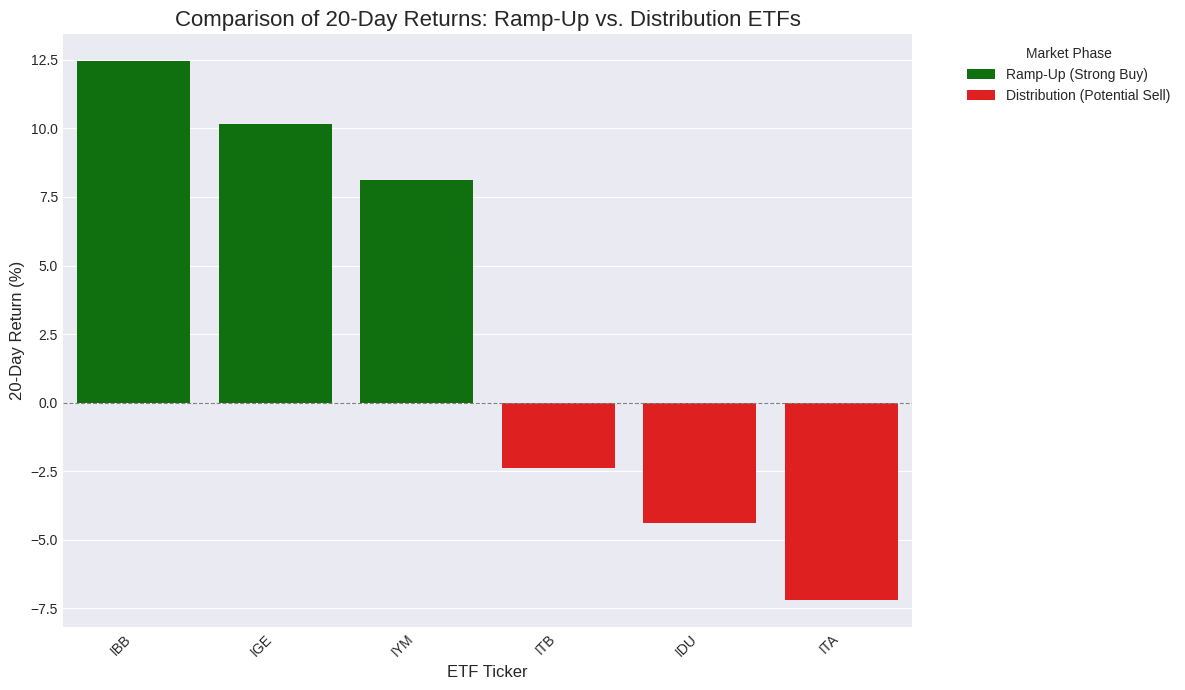

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Ramp-Up and Distribution ETFs
ramp_up_etfs = df_results[df_results['Signal'] == 'Ramp-Up (Strong Buy)']
distribution_etfs = df_results[df_results['Signal'] == 'Distribution (Potential Sell)']

# Combine for comparison
comparison_df = pd.concat([ramp_up_etfs, distribution_etfs])

# Create the bar plot
fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Ticker', y='20D Return', hue='Signal', data=comparison_df.sort_values(by=['Signal', '20D Return'], ascending=[False, False]), palette={'Ramp-Up (Strong Buy)': 'green', 'Distribution (Potential Sell)': 'red'})
plt.title('Comparison of 20-Day Returns: Ramp-Up vs. Distribution ETFs', fontsize=16)
plt.xlabel('ETF Ticker', fontsize=12)
plt.ylabel('20-Day Return (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(title='Market Phase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()